### Load the Dataset

In [5]:
import pandas as pd


df = pd.read_csv("healthcare_los_costs.csv")


In [7]:
# Preview data
df.head()

,patient_id,age,gender,diagnosis,department,admission_date,discharge_date,length_of_stay,daily_cost,total_cost
0,1,51,Male,Infection,Maternity,2023-11-29,2023-12-03,4,131,524
1,2,14,Male,Chronic Disease,Maternity,2023-01-10,2023-01-25,15,180,2700
2,3,71,Female,Routine Check,Surgery,2023-12-24,2024-01-05,12,380,4560
3,4,60,Female,Routine Check,Maternity,2023-07-22,2023-07-30,8,135,1080
4,5,20,Female,Infection,Surgery,2023-07-15,2023-07-22,7,288,2016


### Understand the Structure of the Data

In [10]:
df.shape


(5000, 10)

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      5000 non-null   int64 
 1   age             5000 non-null   int64 
 2   gender          5000 non-null   object
 3   diagnosis       5000 non-null   object
 4   department      5000 non-null   object
 5   admission_date  5000 non-null   object
 6   discharge_date  5000 non-null   object
 7   length_of_stay  5000 non-null   int64 
 8   daily_cost      5000 non-null   int64 
 9   total_cost      5000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


In [14]:
df["admission_date"] = pd.to_datetime(df["admission_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"])


### Data Quality Checks

In [19]:
df.isnull().sum()


patient_id        0
age               0
gender            0
diagnosis         0
department        0
admission_date    0
discharge_date    0
length_of_stay    0
daily_cost        0
total_cost        0
dtype: int64

In [21]:
(df["discharge_date"] - df["admission_date"]).dt.days.describe()


count    5000.000000
mean        6.829200
std         3.929773
min         1.000000
25%         3.000000
50%         7.000000
75%        10.000000
max        21.000000
dtype: float64

In [23]:
(df["length_of_stay"] -
 (df["discharge_date"] - df["admission_date"]).dt.days).value_counts()


0    5000
Name: count, dtype: int64

### Descriptive Statistics (Numerical)

In [26]:
df[["age", "length_of_stay", "daily_cost", "total_cost"]].describe()


,age,length_of_stay,daily_cost,total_cost
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.895400,6.829200,229.559600,1964.699000
std,25.886917,3.929773,173.081757,2520.919166
min,0.000000,1.000000,80.000000,80.000000
25%,21.000000,3.000000,121.000000,440.000000
50%,44.000000,7.000000,153.000000,1008.000000
75%,66.000000,10.000000,284.000000,2442.250000
max,89.000000,21.000000,899.000000,16625.000000


### Categorical Overview

In [29]:
df["department"].value_counts()


department
General Medicine    1506
Surgery             1336
Maternity            968
Pediatrics           723
ICU                  467
Name: count, dtype: int64

In [31]:
df["diagnosis"].value_counts()


diagnosis
Chronic Disease    1036
Routine Check      1016
Infection          1001
Trauma              977
Surgery             970
Name: count, dtype: int64

### Feature Engineering (Early, but Important)

In [34]:
df["admission_month"] = df["admission_date"].dt.to_period("M")


In [36]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 90],
    labels=["Child", "Teen", "Young Adult", "Adult", "Elderly"]
)


# Exploratory Data Analysis (EDA)

### Distribution of Length of Stay (LOS)

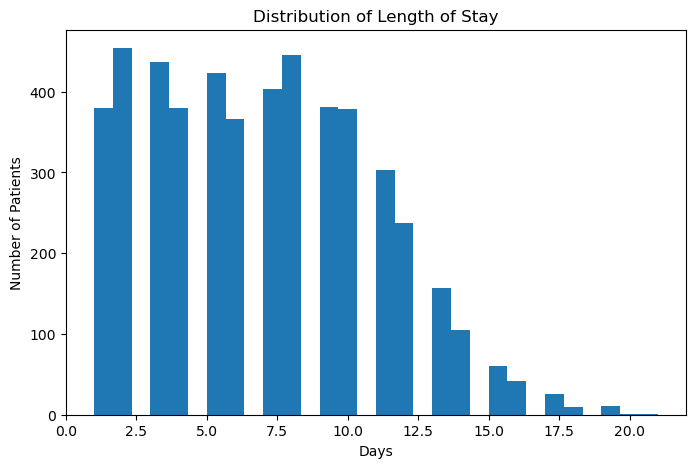

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["length_of_stay"], bins=30)
plt.title("Distribution of Length of Stay")
plt.xlabel("Days")
plt.ylabel("Number of Patients")
plt.show()


### Length of Stay by Department

<Figure size 1000x500 with 0 Axes>

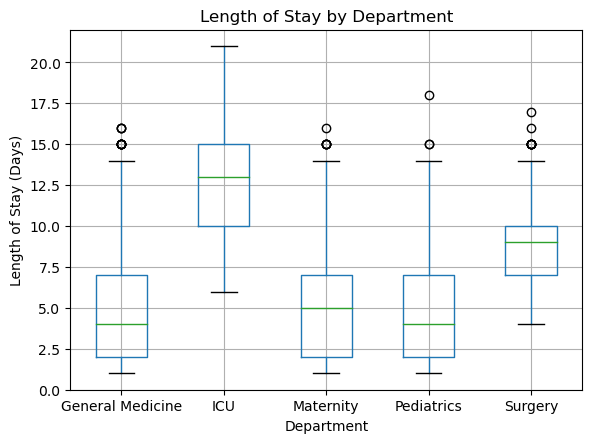

In [43]:
plt.figure(figsize=(10,5))
df.boxplot(column="length_of_stay", by="department")
plt.title("Length of Stay by Department")
plt.suptitle("")
plt.xlabel("Department")
plt.ylabel("Length of Stay (Days)")
plt.show()


### Length of Stay by Diagnosis

<Figure size 1000x500 with 0 Axes>

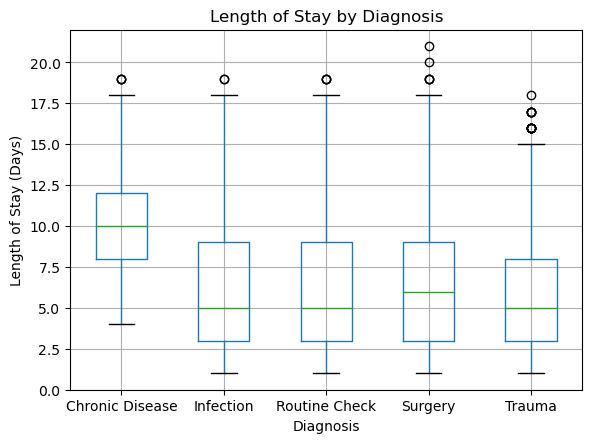

In [46]:
plt.figure(figsize=(10,5))
df.boxplot(column="length_of_stay", by="diagnosis")
plt.title("Length of Stay by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Length of Stay (Days)")
plt.show()


### Cost Analysis (Financial Lens)

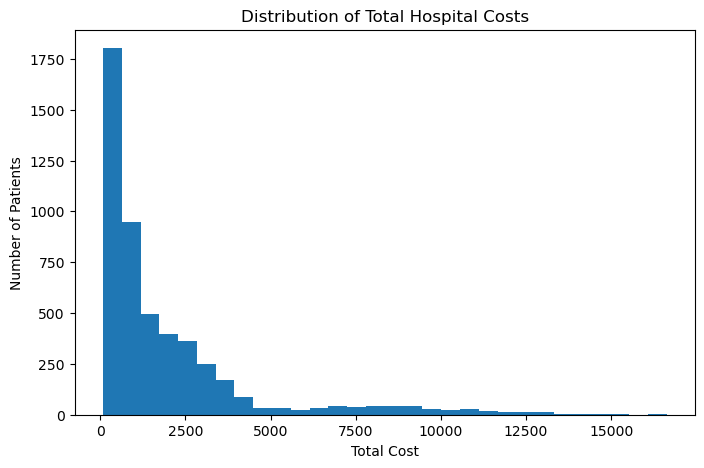

In [49]:
plt.figure(figsize=(8,5))
plt.hist(df["total_cost"], bins=30)
plt.title("Distribution of Total Hospital Costs")
plt.xlabel("Total Cost")
plt.ylabel("Number of Patients")
plt.show()


### Cost by Department

<Figure size 1000x500 with 0 Axes>

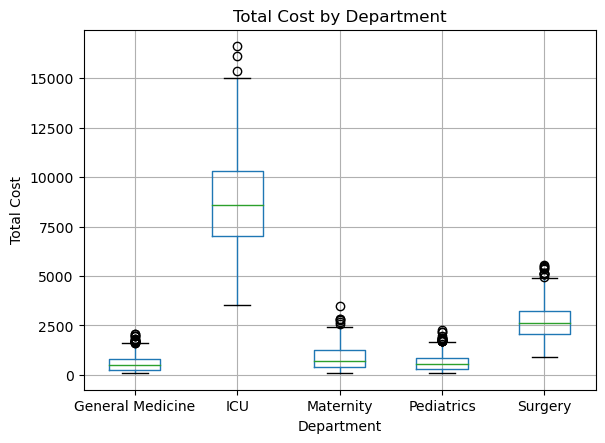

In [52]:
plt.figure(figsize=(10,5))
df.boxplot(column="total_cost", by="department")
plt.title("Total Cost by Department")
plt.suptitle("")
plt.xlabel("Department")
plt.ylabel("Total Cost")
plt.show()


### Relationship Analysis (Key Insight Zone)

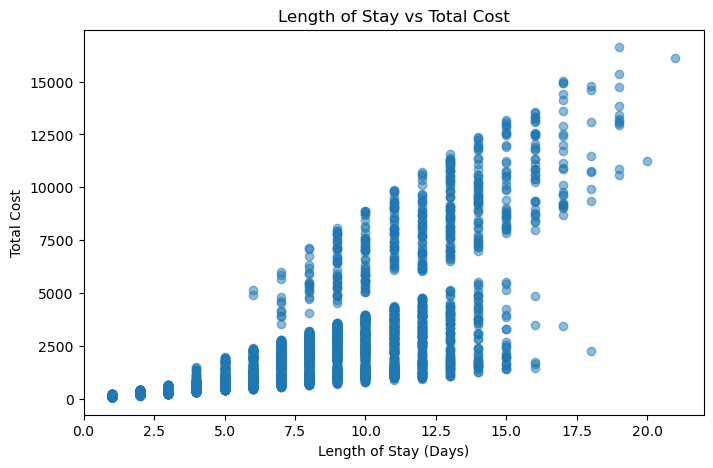

In [55]:
plt.figure(figsize=(8,5))
plt.scatter(df["length_of_stay"], df["total_cost"], alpha=0.5)
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Total Cost")
plt.title("Length of Stay vs Total Cost")
plt.show()


### Age as a Risk Factor

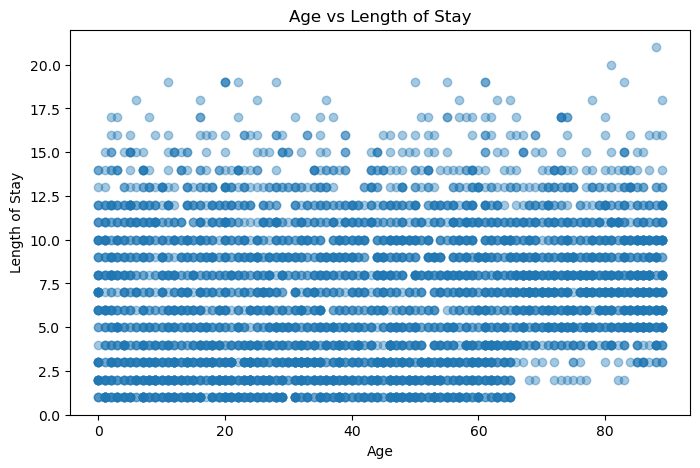

In [58]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["length_of_stay"], alpha=0.4)
plt.xlabel("Age")
plt.ylabel("Length of Stay")
plt.title("Age vs Length of Stay")
plt.show()


### Time-Series Trends (Operational View)

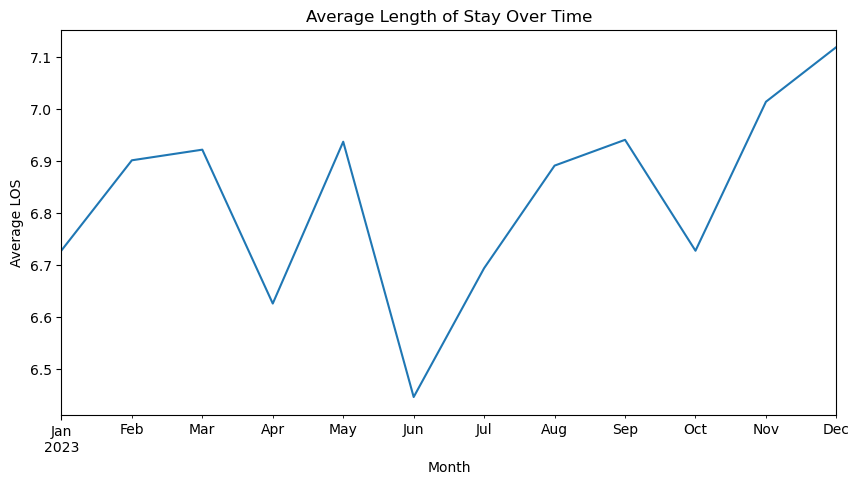

In [61]:
monthly_los = df.groupby("admission_month")["length_of_stay"].mean()

plt.figure(figsize=(10,5))
monthly_los.plot()
plt.title("Average Length of Stay Over Time")
plt.xlabel("Month")
plt.ylabel("Average LOS")
plt.show()


# Stage 3: Hypothesis Testing & Statistical Validation

### Hypothesis 1: Does Length of Stay Differ by Department?

Business Question

Do some departments systematically keep patients longer?

Step 1: Define Hypotheses

H₀ (Null): Mean LOS is the same across all departments

H₁ (Alternative): At least one department has a different mean LOS

### Step 2: Run ANOVA

In [68]:
from scipy.stats import f_oneway

groups = [
    df[df["department"] == dept]["length_of_stay"]
    for dept in df["department"].unique()
]

f_stat, p_value = f_oneway(*groups)

f_stat, p_value


(867.478242353785, 0.0)

p < 0.05 → Reject H₀

LOS significantly differs by department

📌 Portfolio wording:

“Length of stay varies significantly across hospital departments (ANOVA, p < 0.05).”

### Hypothesis 2: Do Chronic Diseases Increase LOS?

Business Question

Are chronic patients staying longer than others?

Hypotheses

H₀: No difference in LOS

H₁: Chronic disease patients have higher LOS

In [74]:
from scipy.stats import ttest_ind

chronic = df[df["diagnosis"] == "Chronic Disease"]["length_of_stay"]
non_chronic = df[df["diagnosis"] != "Chronic Disease"]["length_of_stay"]

t_stat, p_value = ttest_ind(chronic, non_chronic, equal_var=False)

t_stat, p_value


(36.10988836185387, 6.489424578324867e-226)

“Patients with chronic conditions have significantly longer hospital stays than non-chronic patients.”

### Hypothesis 3: Is Age Related to Length of Stay?

Hypotheses

H₀: No correlation between age and LOS

H₁: Positive correlation exists

In [81]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["age"], df["length_of_stay"])

corr, p_value



(0.15154095803090484, 4.5096159566723575e-27)

“Age shows a statistically significant positive correlation with length of stay.”

### Hypothesis 4: Does LOS Drive Total Cost?

Statistical Choice

Pearson correlation

In [86]:
corr_cost, p_value = pearsonr(df["length_of_stay"], df["total_cost"])

corr_cost, p_value


(0.7435492672578403, 0.0)

Length of stay is the strongest predictor of total hospitalization cost

### Optional: Age Group vs LOS (ANOVA)

In [90]:
age_groups = [
    df[df["age_group"] == group]["length_of_stay"]
    for group in df["age_group"].dropna().unique()
]

f_stat, p_value = f_oneway(*age_groups)

f_stat, p_value


(42.83267169699688, 2.238561281914972e-35)

Elderly group significantly different

Supports age-targeted interventions

# Stage 4: Business Insights & Strategic Recommendations

### Insight 1: Length of Stay Is Highly Skewed

What we found

Majority of patients stay a short time

A small group stays much longer

These patients drive most costs

Why it matters

Blanket LOS reduction strategies won’t work

Targeted interventions give better ROI


“A small subset of long-stay patients contributes disproportionately to hospital costs.”

### Insight 2: ICU and Surgery Dominate LOS and Costs

What we found

ICU has the highest median LOS and cost

Surgery shows high variability in LOS

Why it matters

High cost does not automatically mean inefficiency

But variability suggests process improvement potential

“ICU and surgical wards represent the largest cost centers and the greatest opportunities for operational optimisation.”

### Insight 3: Chronic Disease Patients Stay Significantly Longer

What we found

Chronic disease patients have statistically longer LOS

Confirmed via hypothesis testing

Why it matters

These patients benefit from pre-discharge planning

Preventable delays inflate LOS

“Chronic disease management is a key lever for reducing avoidable inpatient days.”

### Insight 4: Elderly Patients Are a High-Risk Group

What we found

Age positively correlates with LOS

Elderly group shows significantly higher stays

Why it matters

Elderly patients require more coordinated care

Discharge delays often non-clinical

“Age-driven LOS increases suggest a need for geriatric-focused care pathways.”

### Insight 5: LOS Is the Primary Cost Driver

What we found

Strong correlation between LOS and total cost

Even small LOS reductions → major savings

“Reducing average LOS by one day can generate substantial cost savings without compromising care quality.”

# Strategic Recommendations (Actionable)

### Recommendation 1: Target Long-Stay Patients Early

Action

Flag patients exceeding LOS thresholds (e.g. >75th percentile)

Daily review by care coordinators

Expected impact

Reduced bed blocking

Faster patient throughput

### Recommendation 2: Department-Specific LOS Benchmarks

Action

Set different LOS targets per department

Avoid one-size-fits-all KPIs

Expected impact

Fair performance evaluation

Clinically justified comparisons

### Recommendation 3: Strengthen Chronic Disease Pathways

Action

Early discharge planning for chronic cases

Improve outpatient follow-ups

Expected impact

Reduced readmissions

Lower inpatient burden

### Recommendation 4: Geriatric Care Coordination

Action

Dedicated discharge teams for elderly patients

Coordinate social services earlier

Expected impact

Reduced non-clinical delays

Improved patient outcomes

### Recommendation 5: Use LOS as a Cost-Control Lever

Action

Monitor LOS daily at department level

Link LOS trends to cost dashboards

Expected impact

Financial transparency

Data-driven budgeting

## KPIs for Dashboards (Very Important)

These are the exact metrics you’ll later display in Power BI:

Average LOS by department

Median LOS

% of patients above LOS threshold

Average cost per patient

Cost per department

LOS trend over time

Elderly patient LOS vs non-elderly

# Stage 5: SQL Analysis 

In [ ]:
hospital_admissions
